In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import seaborn
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split, cross_val_score

     


In [2]:
df = pd.read_csv('heartdisease.csv');

In [3]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,0,110,264,0,0,132,0,1.2,1,0,3,1
299,68,1,3,144,193,1,0,141,0,3.4,1,2,3,1
300,57,1,3,130,131,0,0,115,1,1.2,1,1,3,1
301,57,0,1,130,236,0,2,174,0,0.0,1,1,1,1


In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,2.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,0.600660,0.663366,1.831683,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,0.956705,0.499120
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
df.mean()

age          54.438944
sex           0.679868
cp            2.158416
trestbps    131.689769
chol        246.693069
fbs           0.148515
restecg       0.990099
thalach     149.607261
exang         0.326733
oldpeak       1.039604
slope         0.600660
ca            0.663366
thal          1.831683
target        0.458746
dtype: float64

In [7]:
df.median()

age          56.0
sex           1.0
cp            2.0
trestbps    130.0
chol        241.0
fbs           0.0
restecg       1.0
thalach     153.0
exang         0.0
oldpeak       0.8
slope         1.0
ca            0.0
thal          1.0
target        0.0
dtype: float64

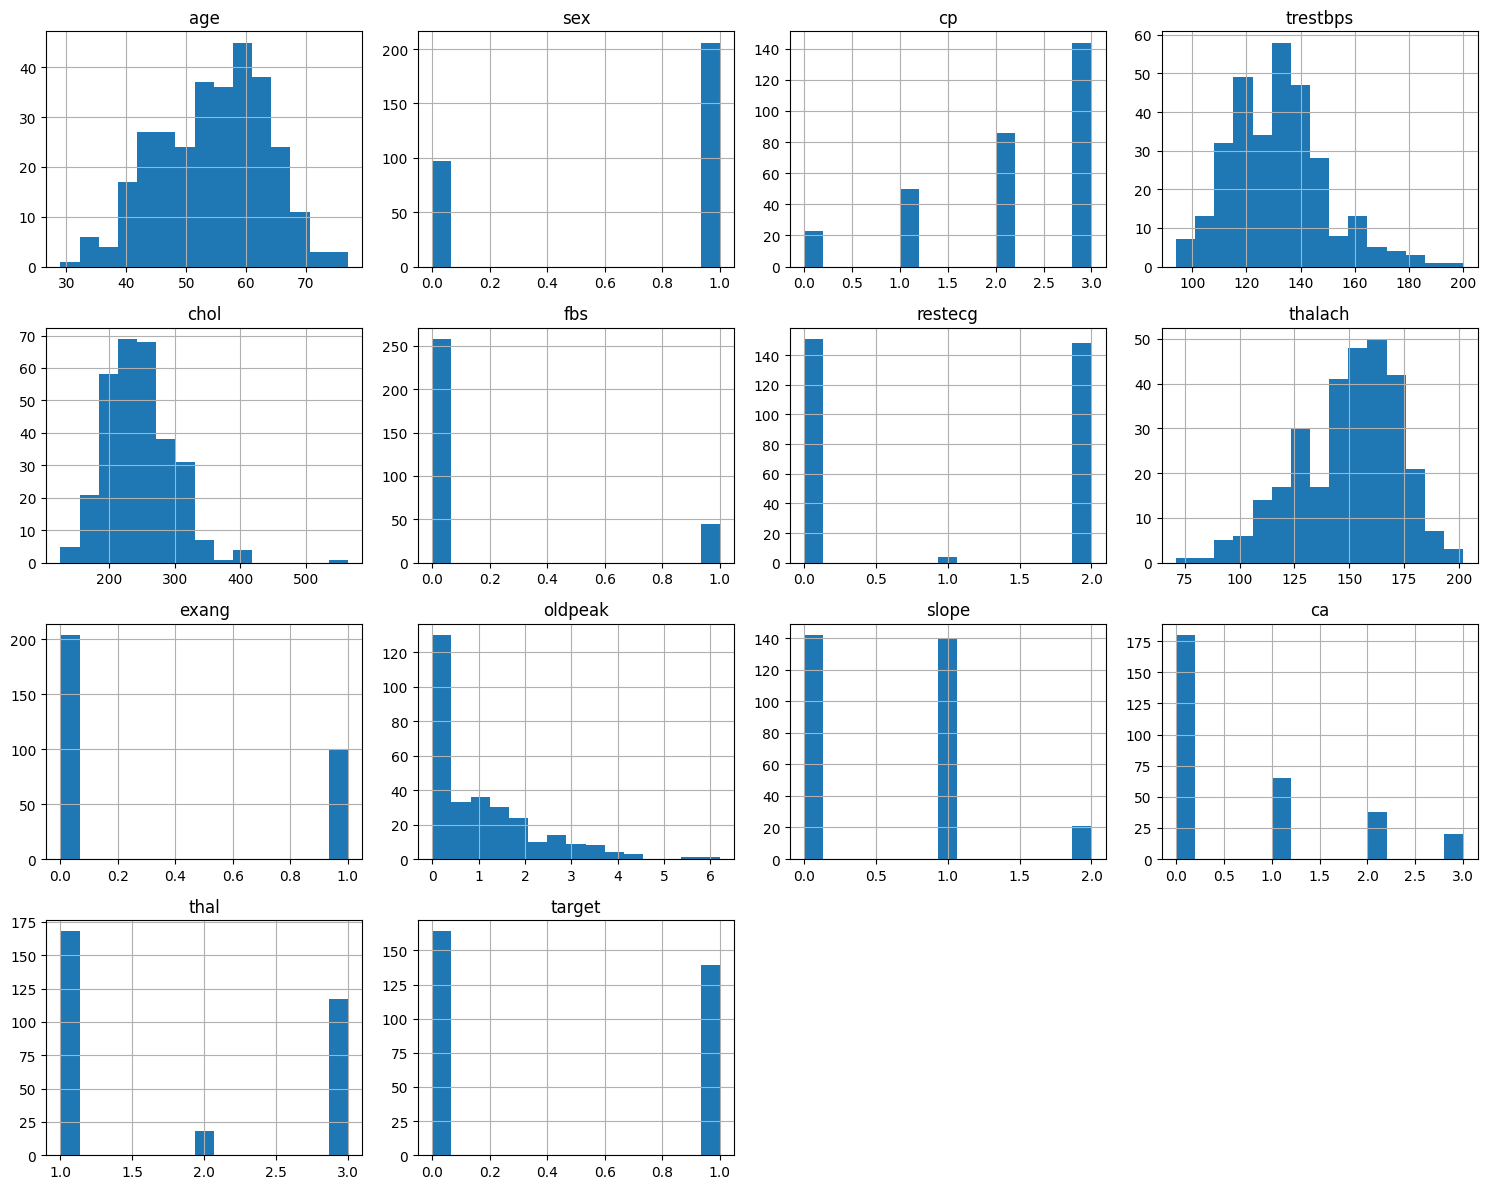

In [8]:
# Create histograms for all numerical columns
df.hist(figsize=(15,12), bins=15)

# Improve spacing
plt.tight_layout()

# Show plots
plt.show()


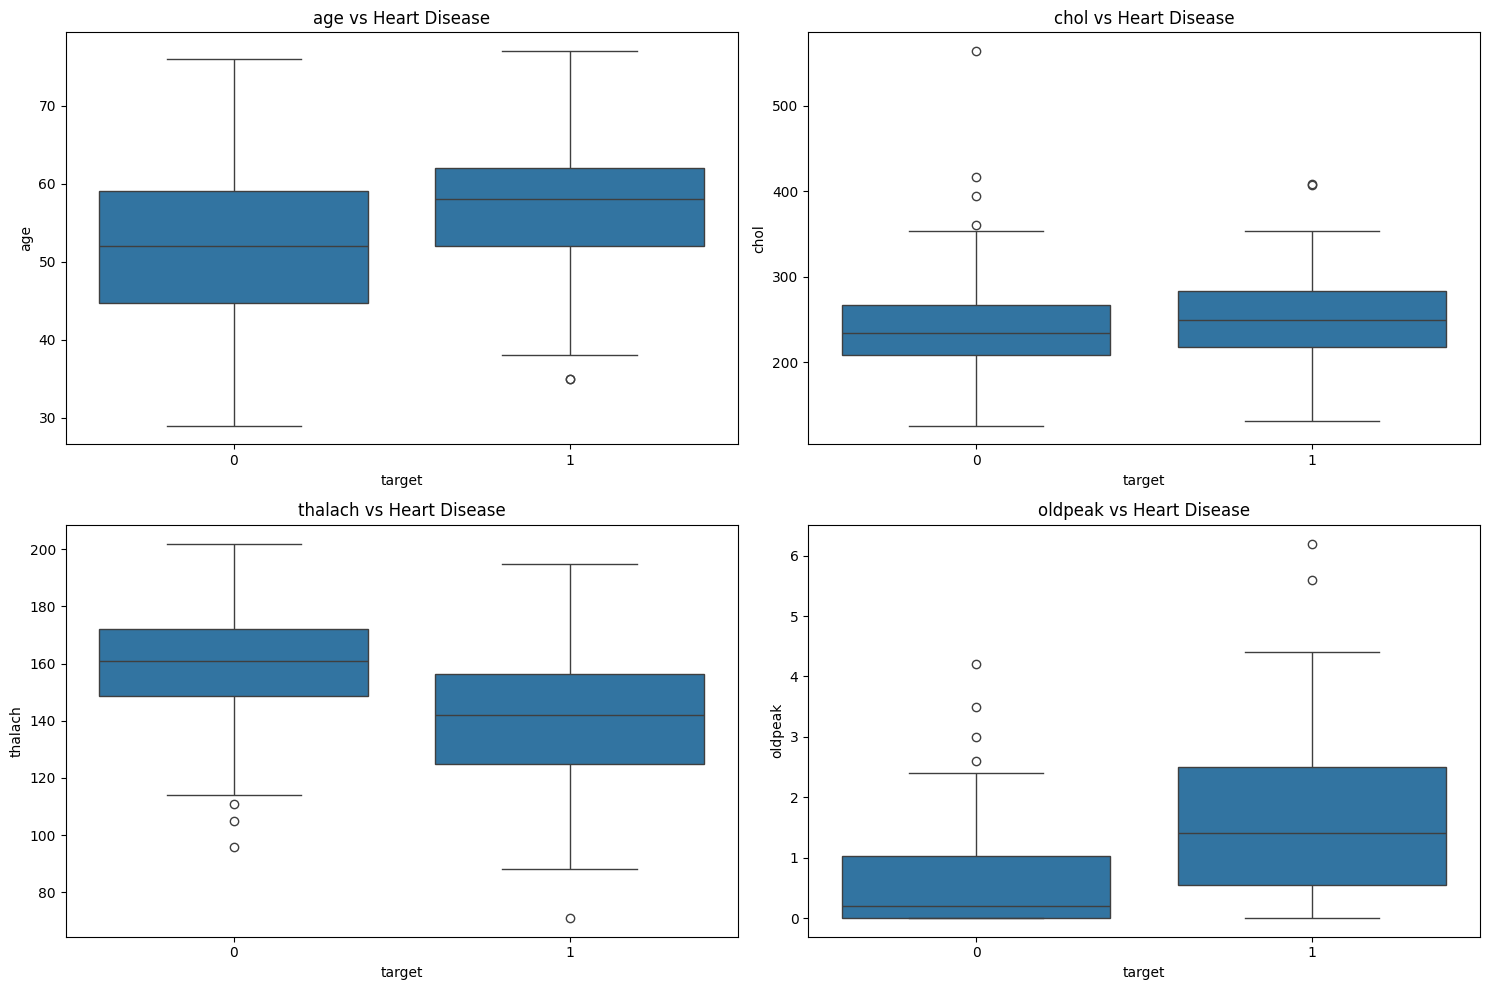

In [9]:
plt.figure(figsize=(15,10))

# List of important numerical features
features = ['age', 'chol', 'thalach', 'oldpeak']

# Create multiple boxplots
for i, feature in enumerate(features, 1):
    
    plt.subplot(2, 2, i)
    
    sns.boxplot(x='target', y=feature, data=df)
    
    plt.title(f'{feature} vs Heart Disease')

# Improve spacing
plt.tight_layout()

# Show plots
plt.show()

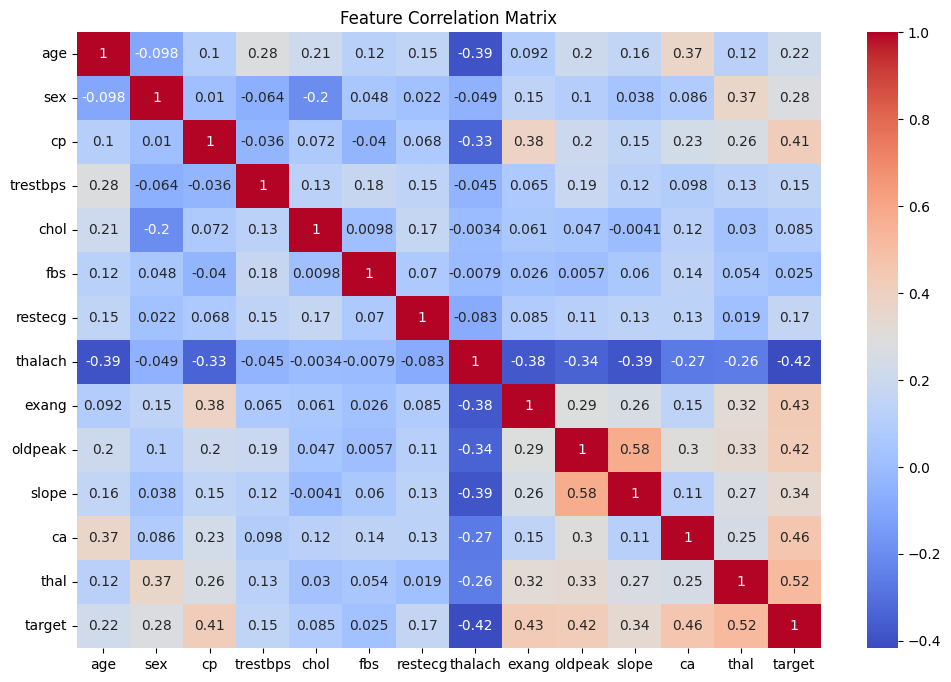

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Matrix")

plt.show()

In [11]:
df['chol_age_ratio'] = df['chol'] / df['age']

In [12]:
# -----------------------------------
# FEATURE ENGINEERING
# -----------------------------------

df['chol_age_ratio'] = df['chol'] / df['age']


# -----------------------------------
# FEATURES AND TARGET
# -----------------------------------

X = df.drop('target', axis=1)

y = df['target']


# -----------------------------------
# TRAIN-TEST SPLIT
# -----------------------------------

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# -----------------------------------
# ONE HOT ENCODING
# -----------------------------------

X_train = pd.get_dummies(X_train, drop_first=True)

X_test = pd.get_dummies(X_test, drop_first=True)


# -----------------------------------
# ALIGN TRAIN AND TEST COLUMNS
# -----------------------------------

X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)


# -----------------------------------
# STANDARD SCALING
# -----------------------------------

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [13]:
#lr without

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Create Logistic Regression model
lr_model = LogisticRegression(random_state=42)

# Train model
lr_model.fit(X_train, y_train)

# Predictions
lr_pred = lr_model.predict(X_test)

# Probability predictions for AUC
lr_prob = lr_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, lr_pred).ravel()

# Metrics
accuracy = accuracy_score(y_test, lr_pred)

sensitivity = recall_score(y_test, lr_pred)

specificity = tn / (tn + fp)

f1 = f1_score(y_test, lr_pred)

auc = roc_auc_score(y_test, lr_prob)

# Results
print("Logistic Regression Results")
print("-----------------------------")

print(f"Accuracy: {accuracy:.4f}")

print(f"Sensitivity (Recall): {sensitivity:.4f}")

print(f"Specificity: {specificity:.4f}")

print(f"F1-score: {f1:.4f}")

print(f"AUC-ROC: {auc:.4f}")

Logistic Regression Results
-----------------------------
Accuracy: 0.8852
Sensitivity (Recall): 0.9062
Specificity: 0.8621
F1-score: 0.8923
AUC-ROC: 0.9203


In [14]:
#XGboost Implementation without bayesian 

from xgboost import XGBClassifier

# Create model
xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Predictions
xgb_pred = xgb_model.predict(X_test)

# Probability predictions for AUC
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, xgb_pred).ravel()

# Metrics
accuracy = accuracy_score(y_test, xgb_pred)

sensitivity = recall_score(y_test, xgb_pred)

specificity = tn / (tn + fp)

f1 = f1_score(y_test, xgb_pred)

auc = roc_auc_score(y_test, xgb_prob)

# Print results
print("XGBoost Performance Metrics")
print("----------------------------")

print(f"Accuracy: {accuracy:.4f}")

print(f"Sensitivity (Recall): {sensitivity:.4f}")

print(f"Specificity: {specificity:.4f}")

print(f"F1-score: {f1:.4f}")

print(f"AUC-ROC: {auc:.4f}")

XGBoost Performance Metrics
----------------------------
Accuracy: 0.8689
Sensitivity (Recall): 0.8125
Specificity: 0.9310
F1-score: 0.8667
AUC-ROC: 0.9343


In [15]:
#Random forest without

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Create model
rf_model = RandomForestClassifier(random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Probability predictions for AUC
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, rf_pred).ravel()

# Metrics
accuracy = accuracy_score(y_test, rf_pred)

sensitivity = recall_score(y_test, rf_pred)

specificity = tn / (tn + fp)

f1 = f1_score(y_test, rf_pred)

auc = roc_auc_score(y_test, rf_prob)

# Results
print("Random Forest Results")
print("-----------------------")

print(f"Accuracy: {accuracy:.4f}")

print(f"Sensitivity (Recall): {sensitivity:.4f}")

print(f"Specificity: {specificity:.4f}")

print(f"F1-score: {f1:.4f}")

print(f"AUC-ROC: {auc:.4f}")

Random Forest Results
-----------------------
Accuracy: 0.8852
Sensitivity (Recall): 0.8750
Specificity: 0.8966
F1-score: 0.8889
AUC-ROC: 0.9278


In [16]:
#Decision tree without

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Create Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train model
dt_model.fit(X_train, y_train)

# Predictions
dt_pred = dt_model.predict(X_test)

# Probability predictions for AUC
dt_prob = dt_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, dt_pred).ravel()

# Metrics
accuracy = accuracy_score(y_test, dt_pred)

sensitivity = recall_score(y_test, dt_pred)

specificity = tn / (tn + fp)

f1 = f1_score(y_test, dt_pred)

auc = roc_auc_score(y_test, dt_prob)

# Results
print("Decision Tree Results")
print("----------------------")

print(f"Accuracy: {accuracy:.4f}")

print(f"Sensitivity (Recall): {sensitivity:.4f}")

print(f"Specificity: {specificity:.4f}")

print(f"F1-score: {f1:.4f}")

print(f"AUC-ROC: {auc:.4f}")

Decision Tree Results
----------------------
Accuracy: 0.7705
Sensitivity (Recall): 0.7188
Specificity: 0.8276
F1-score: 0.7667
AUC-ROC: 0.7732


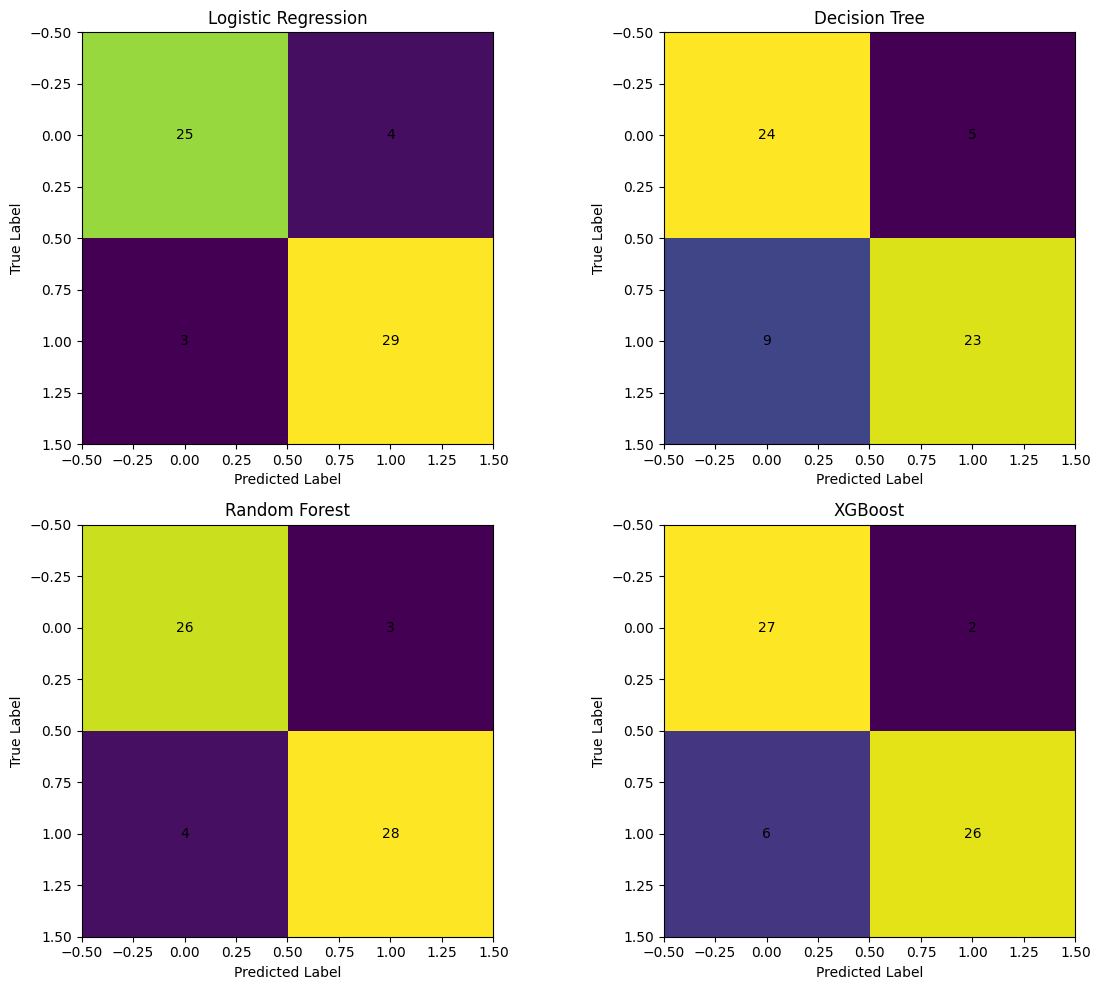

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# -----------------------------------
# CONFUSION MATRICES
# BEFORE BAYESIAN OPTIMIZATION
# -----------------------------------

cm_lr = confusion_matrix(y_test, lr_pred)

cm_dt = confusion_matrix(y_test, dt_pred)

cm_rf = confusion_matrix(y_test, rf_pred)

cm_xgb = confusion_matrix(y_test, xgb_pred)

# -----------------------------------
# MODEL LIST
# -----------------------------------

conf_matrices = [
    cm_lr,
    cm_dt,
    cm_rf,
    cm_xgb
]

titles = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'XGBoost'
]

# -----------------------------------
# CREATE HEATMAPS
# -----------------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, cm, title in zip(axes.flatten(), conf_matrices, titles):

    im = ax.imshow(cm)

    ax.set_title(title)

    ax.set_xlabel('Predicted Label')

    ax.set_ylabel('True Label')

    # Add numbers inside boxes
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):

            ax.text(
                j,
                i,
                cm[i, j],
                ha='center',
                va='center'
            )

# -----------------------------------
# LAYOUT
# -----------------------------------

plt.tight_layout()

plt.show()

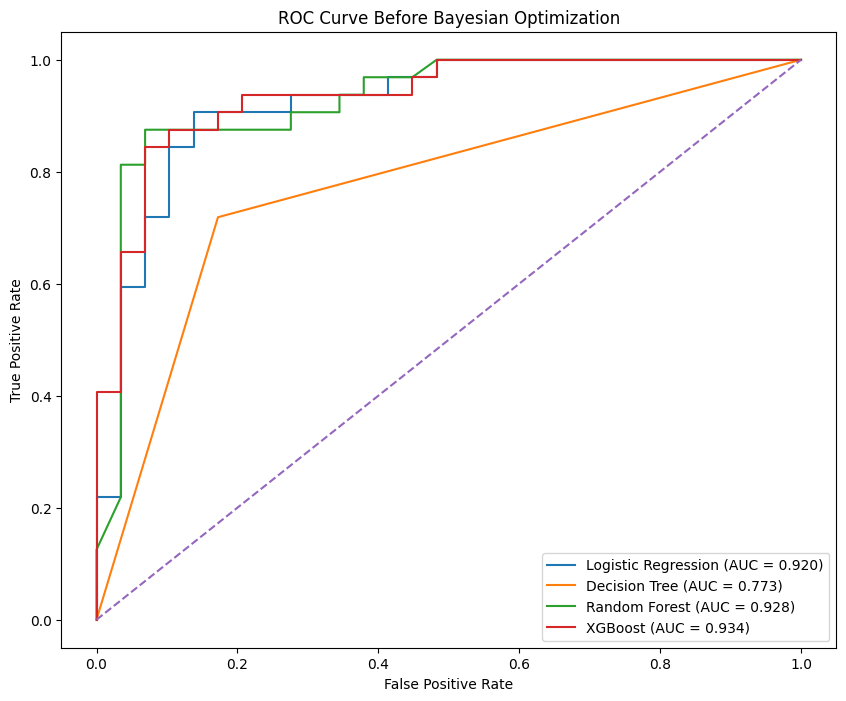

In [18]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# -----------------------------------
# ROC VALUES
# -----------------------------------

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)

dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

# -----------------------------------
# AUC SCORES
# -----------------------------------

lr_auc = auc(lr_fpr, lr_tpr)

dt_auc = auc(dt_fpr, dt_tpr)

rf_auc = auc(rf_fpr, rf_tpr)

xgb_auc = auc(xgb_fpr, xgb_tpr)

# -----------------------------------
# PLOT ROC CURVES
# -----------------------------------

plt.figure(figsize=(10, 8))

plt.plot(lr_fpr, lr_tpr,
         label=f'Logistic Regression (AUC = {lr_auc:.3f})')

plt.plot(dt_fpr, dt_tpr,
         label=f'Decision Tree (AUC = {dt_auc:.3f})')

plt.plot(rf_fpr, rf_tpr,
         label=f'Random Forest (AUC = {rf_auc:.3f})')

plt.plot(xgb_fpr, xgb_tpr,
         label=f'XGBoost (AUC = {xgb_auc:.3f})')

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle='--')

# -----------------------------------
# LABELS
# -----------------------------------

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curve Before Bayesian Optimization')

plt.legend(loc='lower right')

plt.show()

Model Accuracies
-----------------------------
Logistic Regression : 0.8852
Decision Tree       : 0.7705
Random Forest       : 0.8852
XGBoost             : 0.8689


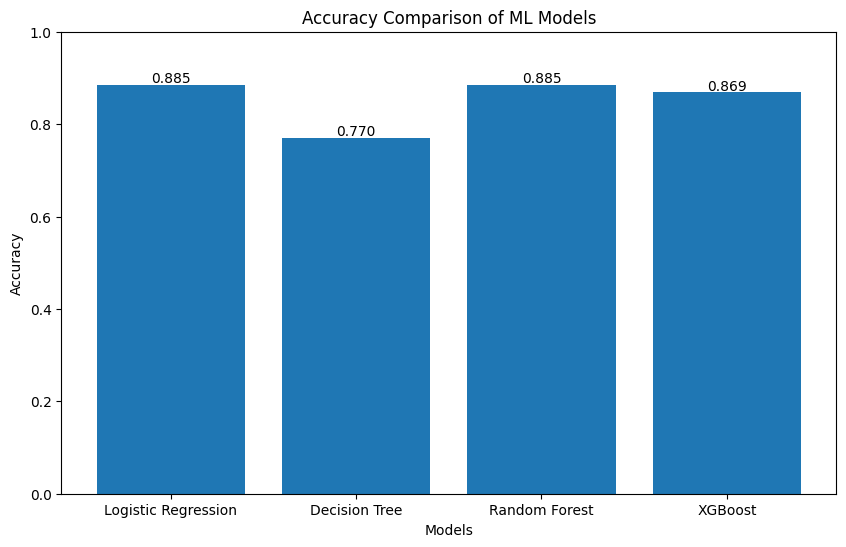

In [19]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# -----------------------------------
# CALCULATE ACCURACIES
# -----------------------------------

lr_accuracy = accuracy_score(y_test, lr_pred)

dt_accuracy = accuracy_score(y_test, dt_pred)

rf_accuracy = accuracy_score(y_test, rf_pred)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

# -----------------------------------
# PRINT ACCURACIES BEFORE PLOT
# -----------------------------------

print("Model Accuracies")
print("-----------------------------")

print(f"Logistic Regression : {lr_accuracy:.4f}")

print(f"Decision Tree       : {dt_accuracy:.4f}")

print(f"Random Forest       : {rf_accuracy:.4f}")

print(f"XGBoost             : {xgb_accuracy:.4f}")

# -----------------------------------
# MODEL NAMES
# -----------------------------------

models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'XGBoost'
]

# -----------------------------------
# ACCURACY VALUES
# -----------------------------------

accuracies = [
    lr_accuracy,
    dt_accuracy,
    rf_accuracy,
    xgb_accuracy
]

# -----------------------------------
# CREATE BAR PLOT
# -----------------------------------

plt.figure(figsize=(10, 6))

plt.bar(models, accuracies)

# -----------------------------------
# LABELS
# -----------------------------------

plt.xlabel('Models')

plt.ylabel('Accuracy')

plt.title('Accuracy Comparison of ML Models')

# -----------------------------------
# DISPLAY VALUES ON BARS
# -----------------------------------

for i, value in enumerate(accuracies):
    plt.text(i, value + 0.005, f'{value:.3f}', ha='center')

# -----------------------------------
# Y LIMIT
# -----------------------------------

plt.ylim(0, 1)

# -----------------------------------
# SHOW PLOT
# -----------------------------------

plt.show()

In [20]:
#lr with

from skopt import BayesSearchCV
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Create Logistic Regression model
lr_model = LogisticRegression(random_state=42)

# Hyperparameter search space
lr_params = {
    'C': (0.001, 100.0, 'log-uniform')
}

# Bayesian Optimization
lr_bayes = BayesSearchCV(
    estimator=lr_model,
    search_spaces=lr_params,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42
)

# Train optimized model
lr_bayes.fit(X_train, y_train)

# Predictions
lr_pred = lr_bayes.predict(X_test)

# Probability predictions for AUC
lr_prob = lr_bayes.predict_proba(X_test)[:, 1]

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, lr_pred).ravel()

# Metrics
accuracy = accuracy_score(y_test, lr_pred)

sensitivity = recall_score(y_test, lr_pred)

specificity = tn / (tn + fp)

f1 = f1_score(y_test, lr_pred)

auc = roc_auc_score(y_test, lr_prob)

# Results
print("Optimized Logistic Regression Results")
print("--------------------------------------")

print("Best Parameters:", lr_bayes.best_params_)

print(f"Accuracy: {accuracy:.4f}")

print(f"Sensitivity (Recall): {sensitivity:.4f}")

print(f"Specificity: {specificity:.4f}")

print(f"F1-score: {f1:.4f}")

print(f"AUC-ROC: {auc:.4f}")

Optimized Logistic Regression Results
--------------------------------------
Best Parameters: OrderedDict({'C': 0.06793176214083133})
Accuracy: 0.8689
Sensitivity (Recall): 0.8750
Specificity: 0.8621
F1-score: 0.8750
AUC-ROC: 0.9310


In [21]:
#XGboost with baynesian

from skopt import BayesSearchCV
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Create XGBoost model
xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

# Hyperparameter search space
xgb_params = {
    'n_estimators': (50, 300),
    'max_depth': (2, 10),
    'learning_rate': (0.01, 0.3, 'log-uniform'),
    'subsample': (0.5, 1.0, 'uniform')
}

# Bayesian Optimization
xgb_bayes = BayesSearchCV(
    estimator=xgb_model,
    search_spaces=xgb_params,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42
)

# Train optimized model
xgb_bayes.fit(X_train, y_train)

# Predictions
xgb_pred = xgb_bayes.predict(X_test)

# Probability predictions for AUC
xgb_prob = xgb_bayes.predict_proba(X_test)[:, 1]

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, xgb_pred).ravel()

# Metrics
accuracy = accuracy_score(y_test, xgb_pred)

sensitivity = recall_score(y_test, xgb_pred)

specificity = tn / (tn + fp)

f1 = f1_score(y_test, xgb_pred)

auc = roc_auc_score(y_test, xgb_prob)

# Results
print("Optimized XGBoost Results")
print("---------------------------")

print("Best Parameters:", xgb_bayes.best_params_)

print(f"Accuracy: {accuracy:.4f}")

print(f"Sensitivity (Recall): {sensitivity:.4f}")

print(f"Specificity: {specificity:.4f}")

print(f"F1-score: {f1:.4f}")

print(f"AUC-ROC: {auc:.4f}")

MemoryError: Unable to allocate 781. KiB for an array with shape (10000, 10) and data type float64

In [ ]:
# -----------------------------------
# RANDOM FOREST WITH BAYESIAN OPTIMIZATION
# FAST + STABLE VERSION
# -----------------------------------

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from sklearn.model_selection import StratifiedKFold
from skopt import BayesSearchCV
import numpy as np


# -----------------------------------
# RANDOM FOREST MODEL
# -----------------------------------

rf_model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)


# -----------------------------------
# SMALLER SEARCH SPACE
# -----------------------------------

rf_params = {

'n_estimators': (100, 400),
'max_depth': (3, 12),
'min_samples_split': (2, 10),
'min_samples_leaf': (1, 5),
'max_features': ['sqrt', 'log2']
}


# -----------------------------------
# CROSS VALIDATION
# -----------------------------------

cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)


# -----------------------------------
# BAYESIAN SEARCH
# -----------------------------------

rf_bayes = BayesSearchCV(

    estimator=rf_model,

    search_spaces=rf_params,

    n_iter=25,

    cv=cv_strategy,

    scoring='roc_auc',

    n_jobs=-1,

    random_state=42,

    verbose=1
)


# -----------------------------------
# TRAIN MODEL
# -----------------------------------

rf_bayes.fit(X_train, y_train)


# -----------------------------------
# PREDICTIONS
# -----------------------------------

rf_pred = rf_bayes.predict(X_test)
rf_prob = rf_bayes.predict_proba(X_test)[:, 1]


# -----------------------------------
# CONFUSION MATRIX
# -----------------------------------

tn, fp, fn, tp = confusion_matrix(
    y_test,
    rf_pred
).ravel()


# -----------------------------------
# METRICS
# -----------------------------------

accuracy = accuracy_score(y_test, rf_pred)
sensitivity = recall_score(y_test, rf_pred)
specificity = tn / (tn + fp)
f1 = f1_score(y_test, rf_pred)
auc = roc_auc_score(y_test, rf_prob)


# -----------------------------------
# RESULTS
# -----------------------------------

print("\nOptimized Random Forest Results")
print("-----------------------------------")

print("Best Parameters:")
print(rf_bayes.best_params_)

print("\nPerformance Metrics")

print(f"Accuracy: {accuracy:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC-ROC: {auc:.4f}")

In [ ]:
#Decision tree with

from skopt import BayesSearchCV
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Create Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Hyperparameter search space
dt_params = {
    'max_depth': (2, 20),
    'min_samples_split': (2, 10),
    'min_samples_leaf': (1, 10)
}

# Bayesian Optimization
dt_bayes = BayesSearchCV(
    estimator=dt_model,
    search_spaces=dt_params,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42
)

# Train optimized model
dt_bayes.fit(X_train, y_train)

# Predictions
dt_pred = dt_bayes.predict(X_test)

# Probability predictions for AUC
dt_prob = dt_bayes.predict_proba(X_test)[:, 1]

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, dt_pred).ravel()

# Metrics
accuracy = accuracy_score(y_test, dt_pred)

sensitivity = recall_score(y_test, dt_pred)

specificity = tn / (tn + fp)

f1 = f1_score(y_test, dt_pred)

auc = roc_auc_score(y_test, dt_prob)

# Results
print("Optimized Decision Tree Results")
print("--------------------------------")

print("Best Parameters:", dt_bayes.best_params_)

print(f"Accuracy: {accuracy:.4f}")

print(f"Sensitivity (Recall): {sensitivity:.4f}")

print(f"Specificity: {specificity:.4f}")

print(f"F1-score: {f1:.4f}")

print(f"AUC-ROC: {auc:.4f}")

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# -----------------------------------
# CONFUSION MATRICES
# BEFORE BAYESIAN OPTIMIZATION
# -----------------------------------

cm_lr = confusion_matrix(y_test, lr_pred)

cm_dt = confusion_matrix(y_test, dt_pred)

cm_rf = confusion_matrix(y_test, rf_pred)

cm_xgb = confusion_matrix(y_test, xgb_pred)

# -----------------------------------
# MODEL LIST
# -----------------------------------

conf_matrices = [
    cm_lr,
    cm_dt,
    cm_rf,
    cm_xgb
]

titles = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'XGBoost'
]

# -----------------------------------
# CREATE HEATMAPS
# -----------------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, cm, title in zip(axes.flatten(), conf_matrices, titles):

    im = ax.imshow(cm)

    ax.set_title(title)

    ax.set_xlabel('Predicted Label')

    ax.set_ylabel('True Label')

    # Add numbers inside boxes
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):

            ax.text(
                j,
                i,
                cm[i, j],
                ha='center',
                va='center'
            )

# -----------------------------------
# LAYOUT
# -----------------------------------

plt.tight_layout()

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# -----------------------------------
# CALCULATE ACCURACIES
# -----------------------------------

lr_accuracy = accuracy_score(y_test, lr_pred)

dt_accuracy = accuracy_score(y_test, dt_pred)

rf_accuracy = accuracy_score(y_test, rf_pred)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

# -----------------------------------
# MODEL NAMES
# -----------------------------------

models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'XGBoost'
]

# -----------------------------------
# ACCURACY VALUES
# -----------------------------------

accuracies = [
    lr_accuracy,
    dt_accuracy,
    rf_accuracy,
    xgb_accuracy
]

# -----------------------------------
# CREATE BAR PLOT
# -----------------------------------

plt.figure(figsize=(10, 6))

plt.bar(models, accuracies)

# -----------------------------------
# LABELS AND TITLE
# -----------------------------------

plt.xlabel('Models')

plt.ylabel('Accuracy')

plt.title('Accuracy Comparison of ML Models')

# -----------------------------------
# DISPLAY VALUES
# -----------------------------------

for i, value in enumerate(accuracies):
    plt.text(i, value + 0.005, f'{value:.3f}', ha='center')

# -----------------------------------
# Y AXIS LIMIT
# -----------------------------------

plt.ylim(0, 1)

# -----------------------------------
# SHOW PLOT
# -----------------------------------

plt.show()

In [ ]:
scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", scores)

print("Mean Accuracy:", np.mean(scores))

print("Standard Deviation:", np.std(scores))

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# -----------------------------------
# ROC VALUES
# -----------------------------------

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)

dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

# -----------------------------------
# AUC SCORES
# -----------------------------------

lr_auc = auc(lr_fpr, lr_tpr)

dt_auc = auc(dt_fpr, dt_tpr)

rf_auc = auc(rf_fpr, rf_tpr)

xgb_auc = auc(xgb_fpr, xgb_tpr)

# -----------------------------------
# PLOT ROC CURVES
# -----------------------------------

plt.figure(figsize=(10, 8))

plt.plot(lr_fpr, lr_tpr,
         label=f'Logistic Regression (AUC = {lr_auc:.3f})')

plt.plot(dt_fpr, dt_tpr,
         label=f'Decision Tree (AUC = {dt_auc:.3f})')

plt.plot(rf_fpr, rf_tpr,
         label=f'Random Forest (AUC = {rf_auc:.3f})')

plt.plot(xgb_fpr, xgb_tpr,
         label=f'XGBoost (AUC = {xgb_auc:.3f})')

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle='--')

# -----------------------------------
# LABELS
# -----------------------------------

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curve Before Bayesian Optimization')

plt.legend(loc='lower right')

plt.show()